# Message k = 1 without Eve with initial state |000>

C:\Users\91797\anaconda3\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


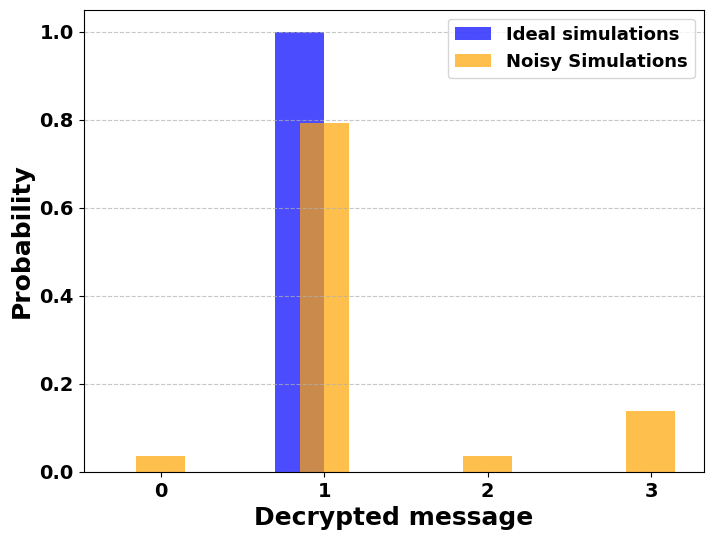

In [2]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFTGate, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

# Alice prepares the public key

qc = QuantumCircuit(6,6)
qc.append(QFTGate(2), [0, 1])
qc.swap(0,1)
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()
qc.p(np.pi,3)
qc.p(np.pi/2,4)
qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.swap(0,1)
qc.append(QFTGate(2).inverse(), [0, 1])
qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]  
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Decrypted message", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

plt.show()